# Semiconductor Wafer Defect Classification: EDA, PCA, and Machine Learning

**Portfolio context:** This project was designed as a clean demonstration notebook based on the MMIE 7310: Machine Learning and Artificial Intelligence for Engineers workflow. It combines EDA, data cleaning, scaling, PCA, classification modeling, class imbalance discussion, hyperparameter tuning, and engineering interpretation.

## Problem Statement

Semiconductor manufacturing relies on tight process control. Small changes in temperature, pressure, gas flow, etch rate, voltage, current, or process step may be associated with wafer defects. The goal of this project is to build a practical machine learning workflow for defect classification and process-quality insight.

## Dataset

The dataset used here is a semiconductor wafer defect classification dataset from Kaggle.

- Kaggle link: add your exact dataset link in the README if public
- Target variable: `defect_label`
- Problem type: supervised classification

## 1. Import Libraries

The workflow uses Python libraries for data analysis, visualization, preprocessing, dimensionality reduction, classification, hyperparameter tuning, and optional neural-network modeling.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, roc_auc_score, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

## 2. Load Data

For GitHub sharing, the dataset file is not included. Download the dataset from Kaggle and place it in the project root as `semiconductor_wafer_defect_dataset.csv`.

In [1]:
DATA_PATH = "semiconductor_wafer_defect_dataset.csv"

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.head()

A sample load data integration from google drive

########################################

from google.colab import drive

drive.mount('/content/drive')

DATA_PATH = '/content/drive/My Drive/Data/Semiconductor_Wafer_Defect_Classification_Dataset/semiconductor_wafer_defect_dataset.csv'

df = pd.read_csv(DATA_PATH)

########################################


## 3. Dataset Overview

This step identifies the number of samples, feature types, target variable, and the process meaning of variables. In process-quality analytics, this helps connect machine learning outputs with manufacturing decisions.

In [4]:
print(f"Number of samples: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

display(df.info())
display(df.head())

Number of samples: 5000
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wafer_id          5000 non-null   int64  
 1   temperature_c     5000 non-null   float64
 2   pressure_torr     5000 non-null   float64
 3   gas_flow_sccm     5000 non-null   float64
 4   etch_rate_nm_min  5000 non-null   float64
 5   voltage_v         5000 non-null   float64
 6   current_ma        5000 non-null   float64
 7   process_step      5000 non-null   object 
 8   defect_label      5000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 351.7+ KB


None

,wafer_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,defect_label
0,1,457.450712,747.287210,113.215053,93.852614,5.139314,20.341747,Deposition,0
1,2,447.926035,746.397577,116.945005,94.738753,5.113329,20.024511,Lithography,0
2,3,459.715328,706.130705,114.026189,95.514359,4.625392,19.137690,Deposition,0
3,4,472.845448,750.097294,121.104180,102.574892,5.231834,19.994947,Deposition,0
4,5,446.487699,781.984872,131.971785,89.022262,4.403967,20.981683,Deposition,0


In [5]:
target = "defect_label"

if "wafer_id" in df.columns:
    id_cols = ["wafer_id"]
else:
    id_cols = []

features = [col for col in df.columns if col not in id_cols + [target]]

numeric_features = df[features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df[features].select_dtypes(exclude=np.number).columns.tolist()

print("ID columns:", id_cols)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)

ID columns: ['wafer_id']
Numeric features: ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma']
Categorical features: ['process_step']
Target: defect_label


## 4. Data Quality Assessment

Missing values, duplicates, and class distribution are checked before modeling. This is especially important in manufacturing classification problems where defect classes may be rare.

In [6]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "data_type": df.dtypes.astype(str)
})
display(quality_summary)

print(f"Duplicate rows: {df.duplicated().sum()}")

,missing_values,missing_percent,unique_values,data_type
wafer_id,0,0.0,5000,int64
temperature_c,0,0.0,5000,float64
pressure_torr,0,0.0,5000,float64
gas_flow_sccm,0,0.0,5000,float64
etch_rate_nm_min,0,0.0,5000,float64
voltage_v,0,0.0,5000,float64
current_ma,0,0.0,5000,float64
process_step,0,0.0,5,object
defect_label,0,0.0,2,int64


Duplicate rows: 0


In [7]:
df_clean = df.drop_duplicates().copy()
print(f"Shape before duplicate removal: {df.shape}")
print(f"Shape after duplicate removal: {df_clean.shape}")

Shape before duplicate removal: (5000, 9)
Shape after duplicate removal: (5000, 9)


## 5. Descriptive Statistics

Descriptive statistics provide a baseline understanding of process-variable ranges and variability.

In [8]:
display(df_clean[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
temperature_c,5000.0,450.084029,14.947197,401.380990,440.131424,450.201984,459.990159,508.893566
pressure_torr,5000.0,759.703783,30.313113,642.327992,739.402513,759.476484,780.317142,865.871656
gas_flow_sccm,5000.0,120.105530,9.987698,86.244209,113.391136,120.099174,126.755342,154.289105
etch_rate_nm_min,5000.0,95.132121,8.026693,64.148997,89.682554,95.154073,100.652917,130.832674
voltage_v,5000.0,4.992659,0.393350,3.537965,4.719296,4.996793,5.260243,6.444540
current_ma,5000.0,19.986853,1.998921,13.093292,18.601549,19.997914,21.354883,27.383249


In [9]:
if categorical_features:
    for col in categorical_features:
        print(f"Value counts for {col}:")
        display(df_clean[col].value_counts())

Value counts for process_step:


,count
process_step,
CMP,1029
Oxidation,1027
Etching,997
Lithography,992
Deposition,955


## 6. Defect Class Distribution and Class Imbalance

Defect classification datasets are often highly imbalanced because failures are rare. Accuracy alone can be misleading, so recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC should be considered.

,count
defect_label,
0,4993
1,7


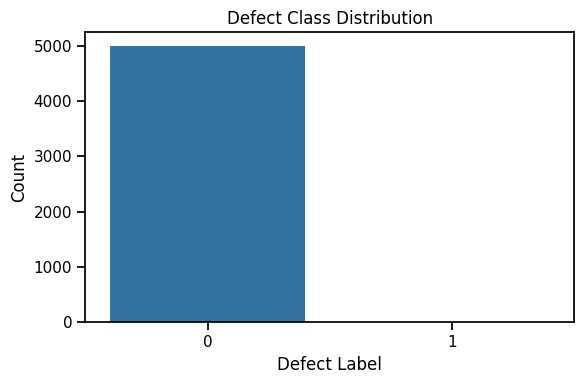

Class percentages:


,percent
defect_label,
0,99.86
1,0.14


In [10]:
class_counts = df_clean[target].value_counts().sort_index()
display(class_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x=target)
plt.title("Defect Class Distribution")
plt.xlabel("Defect Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Class percentages:")
display((class_counts / class_counts.sum() * 100).round(3).to_frame("percent"))

## 7. Univariate Analysis

Histograms and boxplots show the distributions of process variables. These views help identify shifts, skewness, and potential process outliers.

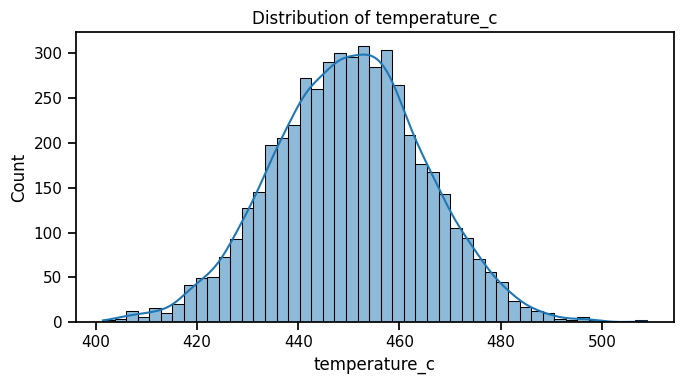

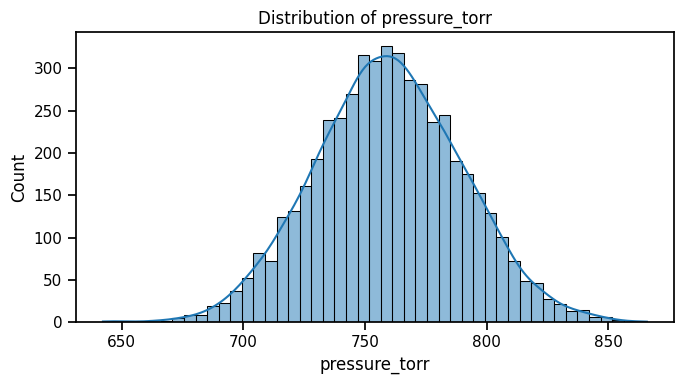

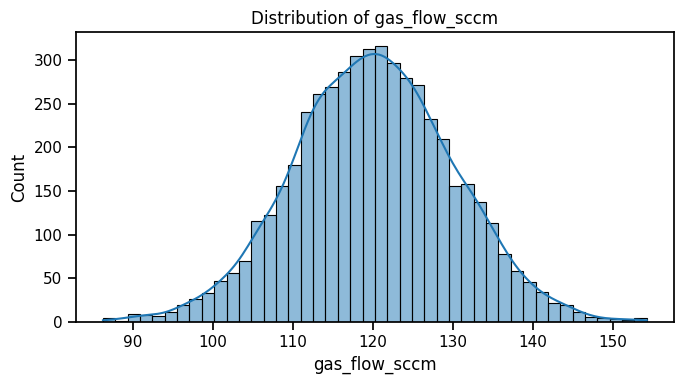

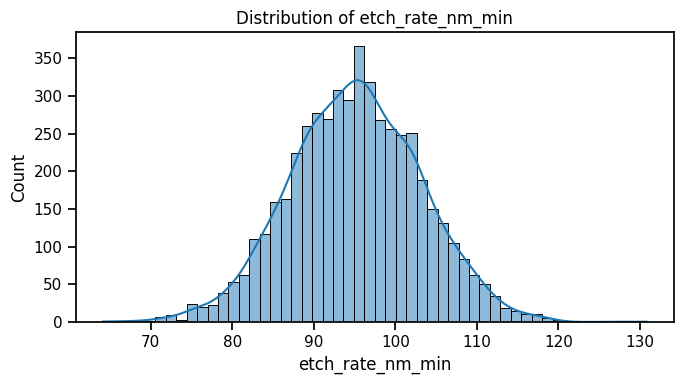

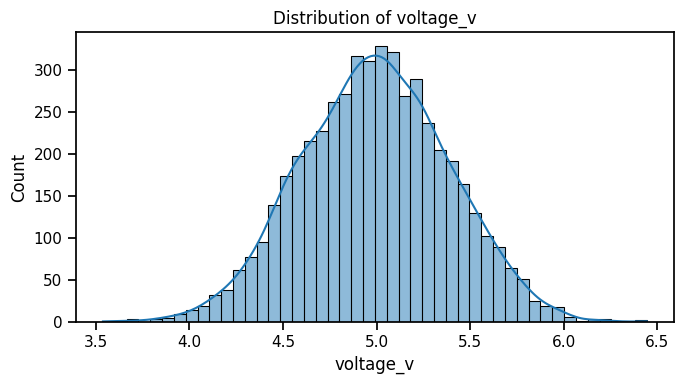

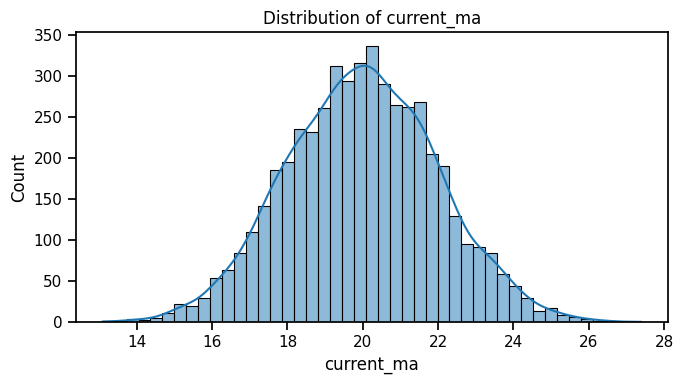

In [11]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

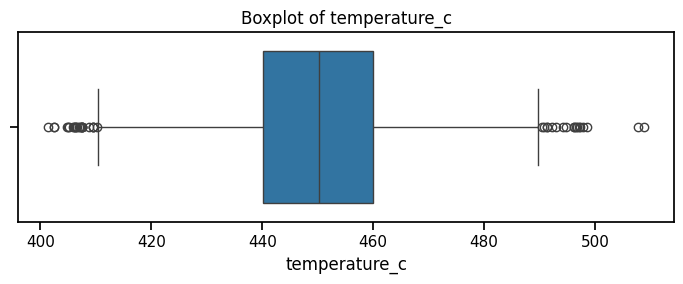

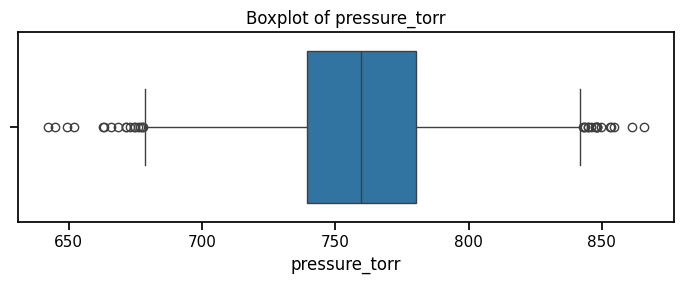

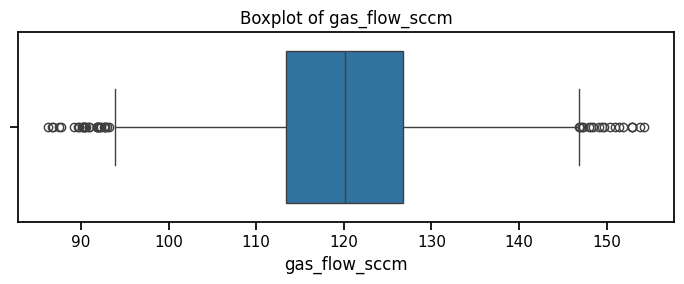

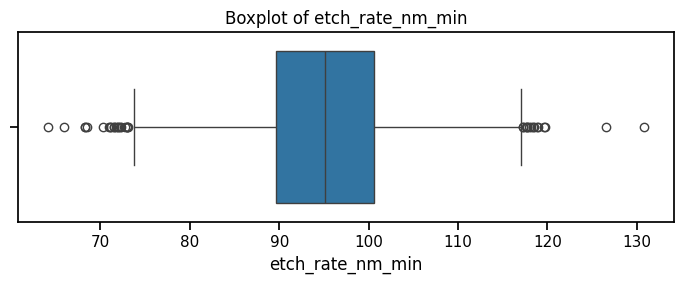

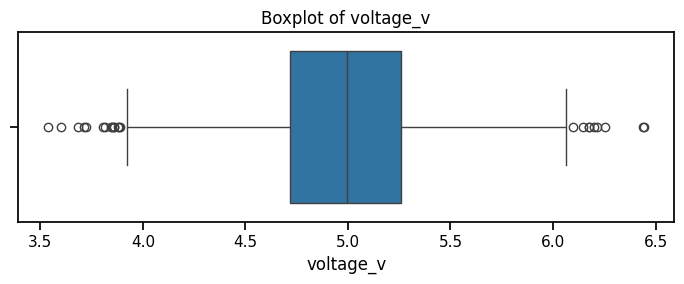

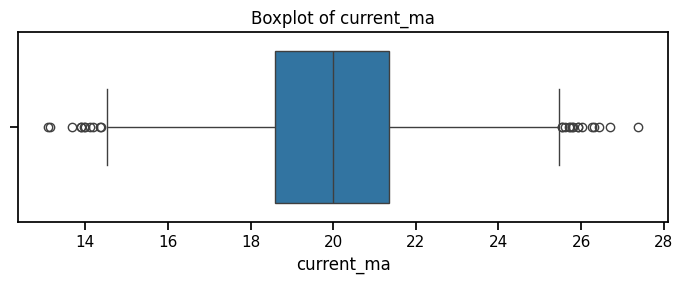

In [12]:
for col in numeric_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 8. Bivariate Analysis

Boxplots grouped by defect label show how process variables differ between normal and defective wafers. This supports root-cause thinking and feature selection.

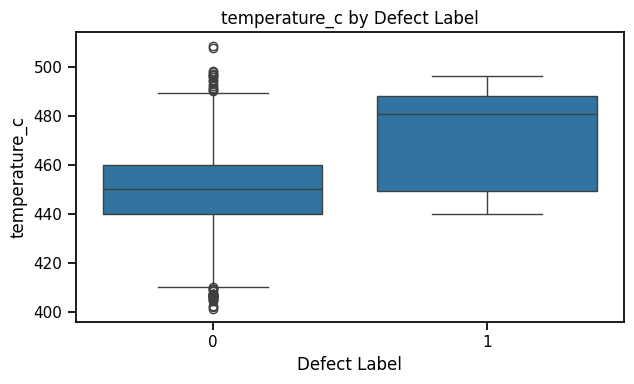

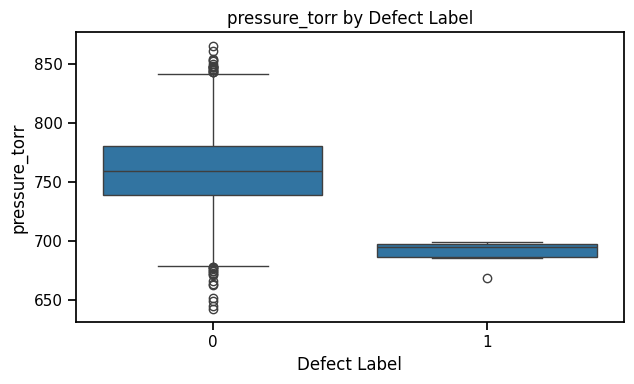

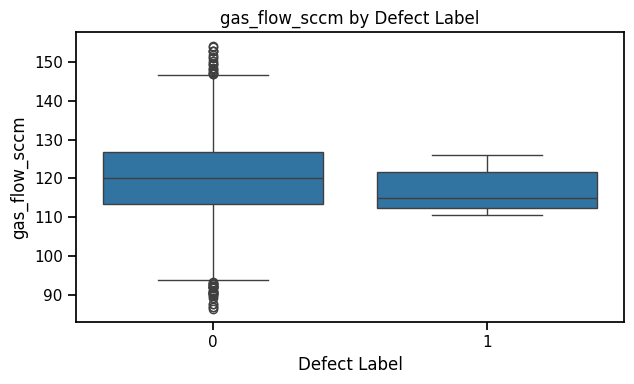

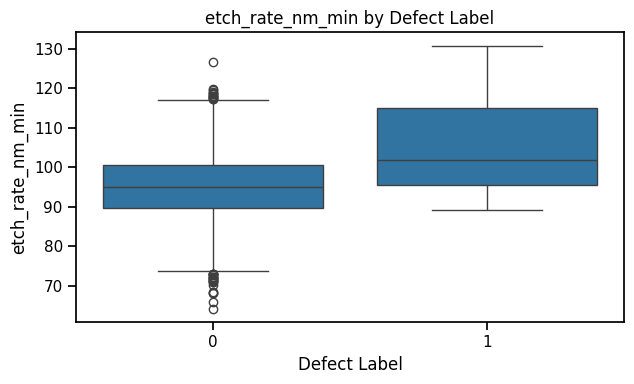

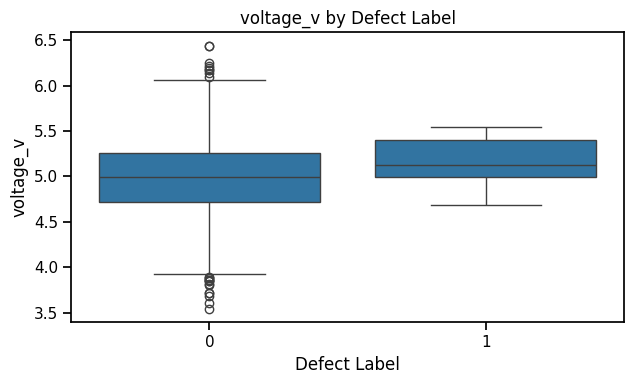

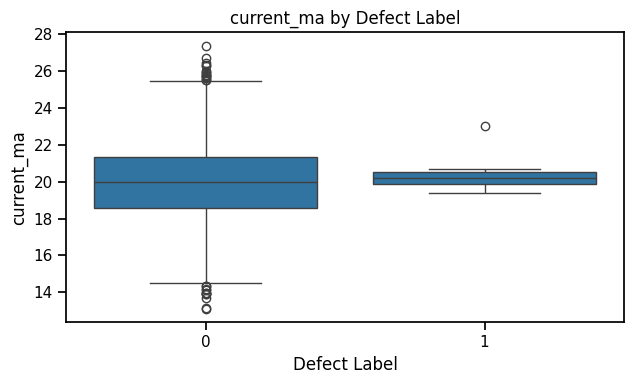

In [13]:
for col in numeric_features:
    plt.figure(figsize=(6.5, 4))
    sns.boxplot(data=df_clean, x=target, y=col)
    plt.title(f"{col} by Defect Label")
    plt.xlabel("Defect Label")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 9. Multivariate Analysis

Correlation analysis helps identify redundant sensor/process variables. Redundant variables may not harm tree models, but can affect linear models and distance-based methods.

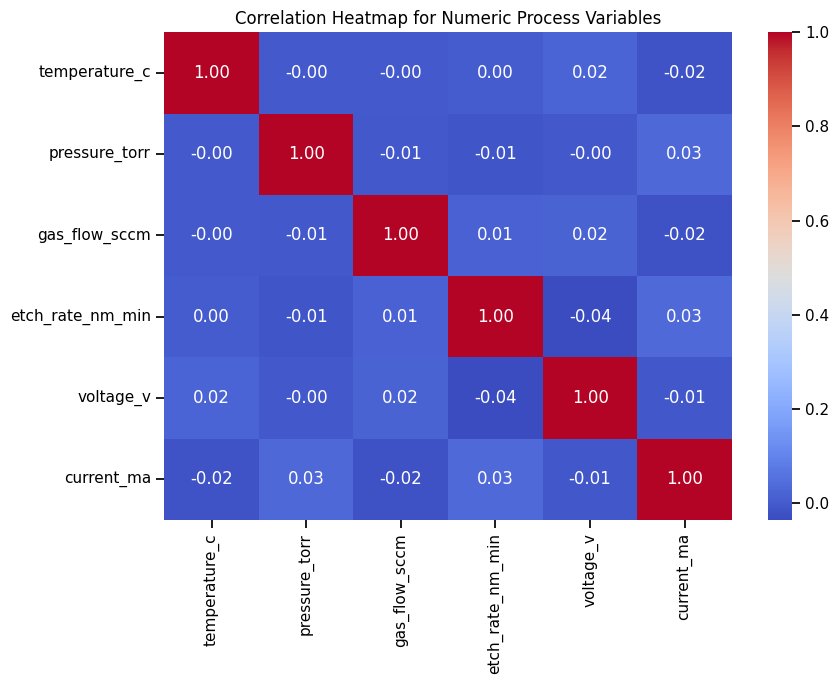

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Numeric Process Variables")
plt.tight_layout()
plt.show()

## 10. Feature Scaling and Normalization

Scaling is critical for PCA, kNN, SVM, logistic regression, and ANN models. The scaler should be fit only on the training set during modeling to avoid data leakage.

In [15]:
X = df_clean[features]
y = df_clean[target]

standard_scaler = StandardScaler()
X_num_standard = pd.DataFrame(standard_scaler.fit_transform(df_clean[numeric_features]), columns=numeric_features)

display(X_num_standard.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
temperature_c,-2.501110e-16,1.0001,-3.258665,3.934879
pressure_torr,5.698553e-16,1.0001,-3.872500,3.502725
gas_flow_sccm,3.291234e-15,1.0001,-3.390642,3.422910
etch_rate_nm_min,4.064304e-16,1.0001,-3.860397,4.448173
voltage_v,-1.575984e-15,1.0001,-3.698588,3.691437
current_ma,3.296918e-16,1.0001,-3.448986,3.700564


## 11. PCA for Dimensionality Reduction and Visualization

PCA projects scaled numeric variables into lower-dimensional components. This can reveal whether defect classes show separability in multivariate process space.

Explained variance ratio: [0.17796089 0.17119985]
Total explained variance: 0.34916074756286475


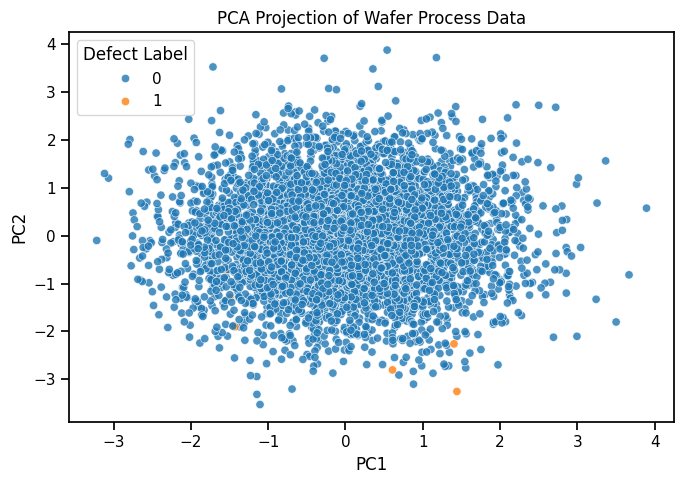

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pc = pca.fit_transform(X_num_standard)

pca_df = pd.DataFrame(pc, columns=["PC1", "PC2"])
pca_df[target] = y.values

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=target, alpha=0.8)
plt.title("PCA Projection of Wafer Process Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Defect Label")
plt.tight_layout()
plt.show()

## 12. Train-Test Split and Preprocessing Pipeline

The pipeline applies standard scaling to numeric features and one-hot encoding to categorical features. This is the preferred structure for reproducible ML workflows.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y if y.nunique() > 1 else None
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4000, 7) (1000, 7)
defect_label
0    3994
1       6
Name: count, dtype: int64
defect_label
0    999
1      1
Name: count, dtype: int64


## 13. Classification Models

We compare multiple classifiers:

1. Logistic Regression  
2. k-Nearest Neighbors  
3. Decision Tree Classifier  
4. Random Forest Classifier  
5. Support Vector Machine  

Because defects may be rare, we report both standard and imbalance-aware metrics.

In [18]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    }

    # Probability metrics if available
    try:
        proba = model.predict_proba(X_test)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_test, proba)
        metrics["pr_auc"] = average_precision_score(y_test, proba)
    except Exception:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics, model, pred

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "kNN": Pipeline([
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "SVM RBF": Pipeline([
        ("preprocess", preprocess),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", probability=True, random_state=RANDOM_STATE))
    ])
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    metrics, fitted_model, pred = evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    results.append(metrics)
    fitted_models[name] = fitted_model
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values(["f1", "balanced_accuracy"], ascending=False)
display(results_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
4,SVM RBF,1.000,1.000000,1.000000,1.0,1.0,1.000000,1.000000
2,Decision Tree,0.998,0.998999,0.333333,1.0,0.5,0.998999,0.333333
1,kNN,0.999,0.500000,0.000000,0.0,0.0,1.000000,1.000000
3,Random Forest,0.999,0.500000,0.000000,0.0,0.0,0.998999,0.500000
0,Logistic Regression,0.990,0.495495,0.000000,0.0,0.0,0.990991,0.100000


## 14. Classification Reports and Confusion Matrices

Confusion matrices are essential for defect detection because false negatives can be costly in quality-control applications.

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       999
           1       0.00      0.00      0.00         1

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      0.99      0.99      1000



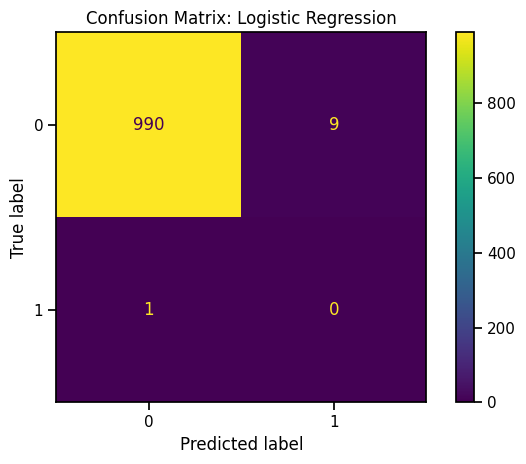

kNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



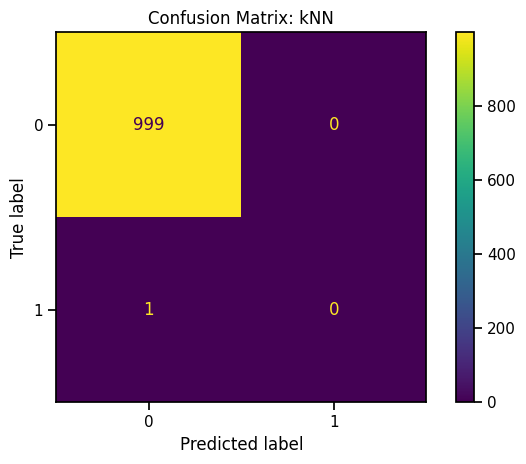

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.33      1.00      0.50         1

    accuracy                           1.00      1000
   macro avg       0.67      1.00      0.75      1000
weighted avg       1.00      1.00      1.00      1000



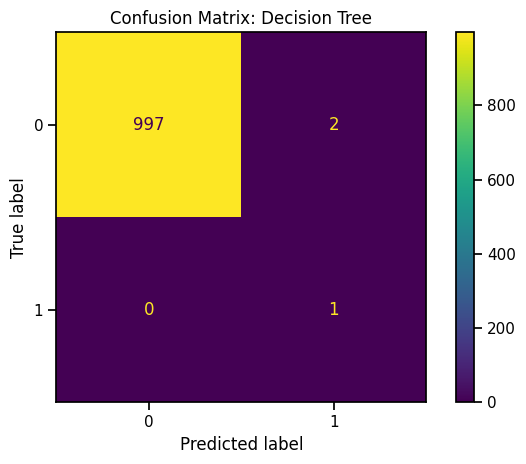

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



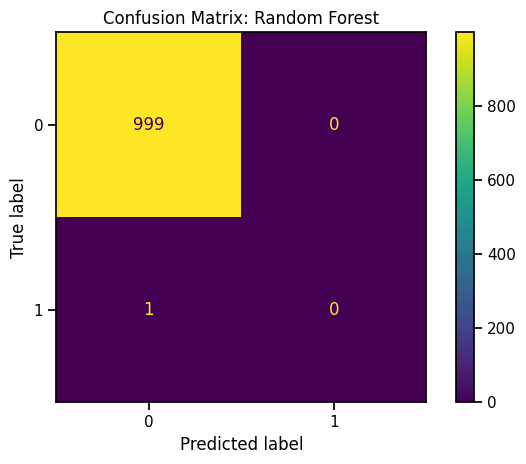

SVM RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       1.00      1.00      1.00         1

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



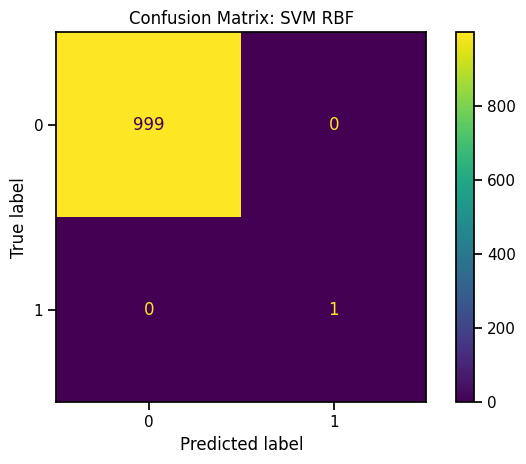

In [19]:
for name, pred in predictions.items():
    print("=" * 80)
    print(name)
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

## 15. Hyperparameter Tuning

We tune the random forest classifier because it is robust for tabular manufacturing data and provides feature importance.

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV F1: 0.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



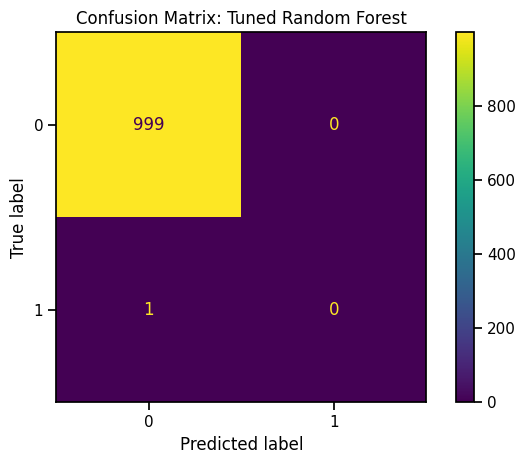

In [20]:
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 4, 8],
    "model__min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title("Confusion Matrix: Tuned Random Forest")
plt.tight_layout()
plt.show()

## 16. Feature Importance

Feature importance helps identify which process variables contribute most to defect prediction. This supports process investigation and quality-improvement discussions.

,feature,importance
1,num__pressure_torr,0.401305
3,num__etch_rate_nm_min,0.220407
0,num__temperature_c,0.129135
4,num__voltage_v,0.076865
5,num__current_ma,0.075547
2,num__gas_flow_sccm,0.050652
6,cat__process_step_CMP,0.019219
9,cat__process_step_Lithography,0.010697
7,cat__process_step_Deposition,0.006932
8,cat__process_step_Etching,0.005065


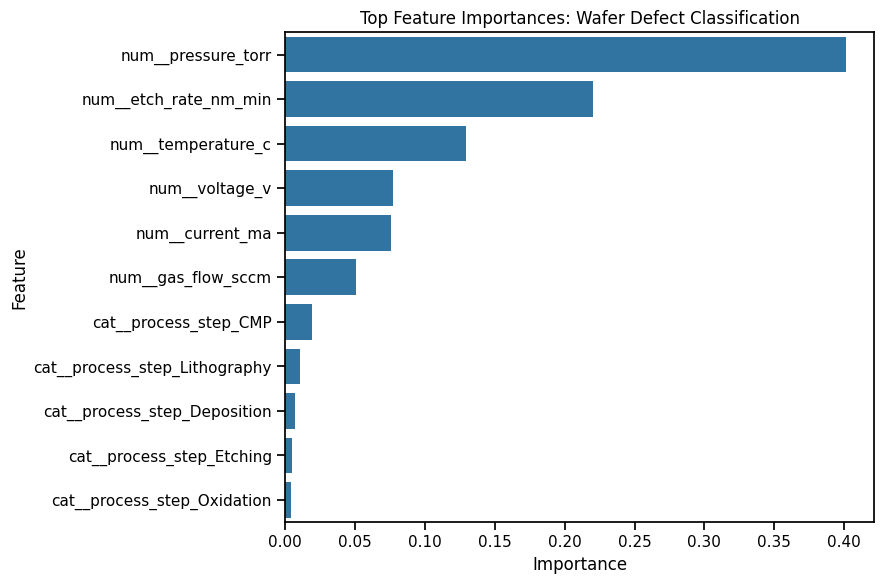

In [21]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

rf = best_model.named_steps["model"]
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top Feature Importances: Wafer Defect Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 17. Optional ANN Classification Model

This optional section demonstrates a small neural-network classifier. If TensorFlow is not installed, this cell can be skipped.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



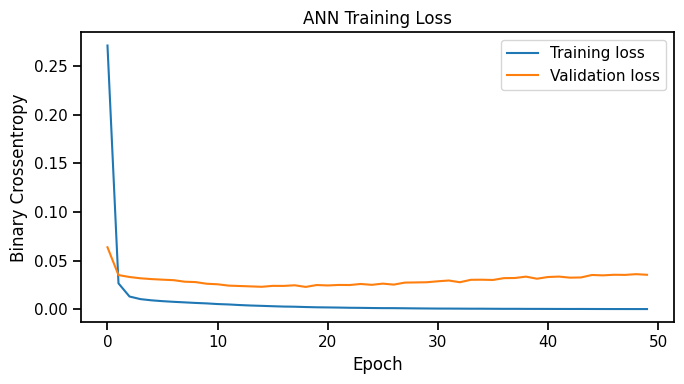

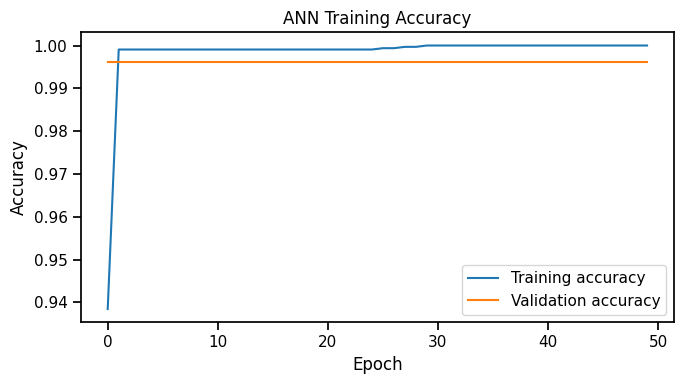

In [22]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    # Preprocess data into arrays
    X_train_arr = preprocess.fit_transform(X_train)
    X_test_arr = preprocess.transform(X_test)

    # Convert sparse matrix to dense if needed
    if hasattr(X_train_arr, "toarray"):
        X_train_arr = X_train_arr.toarray()
        X_test_arr = X_test_arr.toarray()

    ann = keras.Sequential([
        layers.Input(shape=(X_train_arr.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    ann.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]
    )

    history = ann.fit(
        X_train_arr, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    ann_proba = ann.predict(X_test_arr).ravel()
    ann_pred = (ann_proba >= 0.5).astype(int)

    print(classification_report(y_test, ann_pred, zero_division=0))

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title("ANN Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Crossentropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title("ANN Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError:
    print("TensorFlow is not installed. Install tensorflow to run the ANN section.")

## 18. Engineering Interpretation and Conclusions

Key conclusions to document after running the notebook:

- Wafer defect detection is a process-quality classification problem.
- Class imbalance must be handled carefully; high accuracy can be misleading.
- Scaling is important for PCA, kNN, SVM, logistic regression, and neural-network models.
- PCA helps visualize separability but does not guarantee classification performance.
- Feature importance can help prioritize process variables for quality investigation.
- The workflow is transferable to manufacturing analytics, process monitoring, and supplier-quality risk detection.